In [ ]:
from google.colab import files
import zipfile, os

uploaded = files.upload()
zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("FER_DATA")

print("Folders found inside FER_DATA:")
print(os.listdir("FER_DATA"))



NameError: name 'uploaded' is not defined

In [ ]:
#  #Step3_Data_Augmentation
# Load the images using ImageDataGenerator with data augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define ImageDataGenerators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Load training and validation data
train_generator = train_datagen.flow_from_directory(
    "FER_DATA/images/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    "FER_DATA/images/validation",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Check class labels
print("Class Indices:")
print(train_generator.class_indices)


Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Class Indices:
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Load MobileNetV2 without the top layer
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze the base model

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

# Final model
model = Model(inputs=base_model.input, outputs=output)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled successfully!")


✅ Model compiled successfully!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)
checkpoint = ModelCheckpoint("emotion_model_mobilenet.keras", monitor='val_accuracy', save_best_only=True)

# Training the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 1/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 356s 395ms/step - accuracy: 0.2720 - loss: 1.8118 - val_accuracy: 0.3735 - val_loss: 1.6206 - learning_rate: 1.0000e-04
Epoch 2/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 348s 386ms/step - accuracy: 0.3460 - loss: 1.6688 - val_accuracy: 0.3987 - val_loss: 1.5647 - learning_rate: 1.0000e-04
Epoch 3/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 337s 374ms/step - accuracy: 0.3742 - loss: 1.6112 - val_accuracy: 0.4178 - val_loss: 1.5179 - learning_rate: 1.0000e-04
Epoch 4/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 341s 378ms/step - accuracy: 0.3886 - loss: 1.5716 - val_accuracy: 0.4224 - val_loss: 1.5064 - learning_rate: 1.0000e-04
Epoch 5/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 341s 379ms/step - accuracy: 0.3946 - loss: 1.5580 - val_accuracy: 0.4350 - val_loss: 1.4734 - learning_rate: 1.0000e-04
Epoch 6/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 331s 367ms/step - accuracy: 0.4010 - loss: 1.5441 - val_accuracy: 0.4411 - val_loss: 1.4703 - learning_rate: 1.0000e-04
Epoch 7/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
from tensorflow.keras.models import load_model
model.save("emotion_model_mobilenet_20epoch.keras")


In [ ]:
model = load_model("emotion_model_mobilenet_20epoch.keras")

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)
checkpoint = ModelCheckpoint("emotion_model_resnet50.keras", monitor='val_accuracy', save_best_only=True)

# Train
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 1/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 378s 419ms/step - accuracy: 0.2246 - loss: 1.8512 - val_accuracy: 0.2605 - val_loss: 1.8097 - learning_rate: 1.0000e-04
Epoch 2/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 358s 398ms/step - accuracy: 0.2370 - loss: 1.8267 - val_accuracy: 0.2604 - val_loss: 1.8070 - learning_rate: 1.0000e-04
Epoch 3/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 359s 398ms/step - accuracy: 0.2419 - loss: 1.8177 - val_accuracy: 0.2600 - val_loss: 1.7991 - learning_rate: 1.0000e-04
Epoch 4/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 359s 398ms/step - accuracy: 0.2408 - loss: 1.8149 - val_accuracy: 0.2645 - val_loss: 1.7981 - learning_rate: 1.0000e-04
Epoch 5/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 359s 399ms/step - accuracy: 0.2447 - loss: 1.8133 - val_accuracy: 0.2644 - val_loss: 1.7923 - learning_rate: 1.0000e-04
Epoch 6/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 360s 399ms/step - accuracy: 0.2503 - loss: 1.8054 - val_accuracy: 0.2632 - val_loss: 1.7908 - learning_rate: 1.0000e-04
Epoch 7/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 

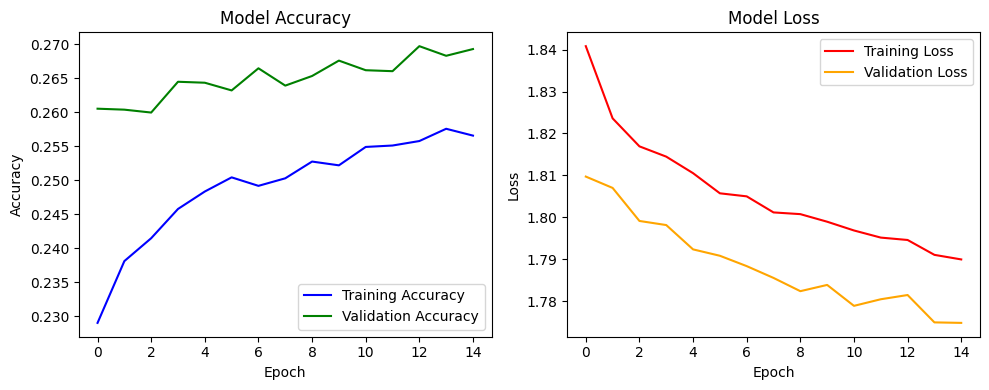

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
from google.colab import files
files.download('emotion_model_mobilenet_20epoch.keras')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>